In [11]:
#Import Pandas + Load Dataset:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("✅ Ready! Shape:", df.shape)
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Shape:", df.shape)
df.head()

✅ Ready! Shape: (1470, 35)
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [12]:
#Check Columns, Missing Values, Attrition Counts:
print("Column Names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nAttrition Counts:")
print(df['Attrition'].value_counts())

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset Info:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
En

Attrition Rate: 16.12%
Retention Rate: 83.88%


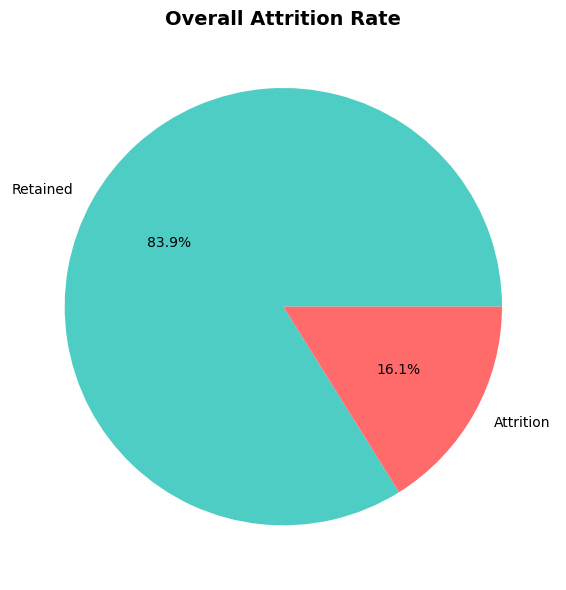

In [13]:
#Attrition Rate Pie Chart:

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Calculate attrition rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(f"Attrition Rate: {attrition_rate['Yes']:.2f}%")
print(f"Retention Rate: {attrition_rate['No']:.2f}%")

# Fixed Pie Chart
plt.figure(figsize=(6,6))
attrition_rate.plot(kind='pie', autopct='%1.1f%%',
                    colors=['#4ecdc4','#ff6b6b'],
                    labels=['Retained','Attrition'])
plt.title('Overall Attrition Rate', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('attrition_rate.png', dpi=150)
plt.show()

               Department  Attrition_Rate
0         Human Resources       19.047619
1  Research & Development       13.839750
2                   Sales       20.627803


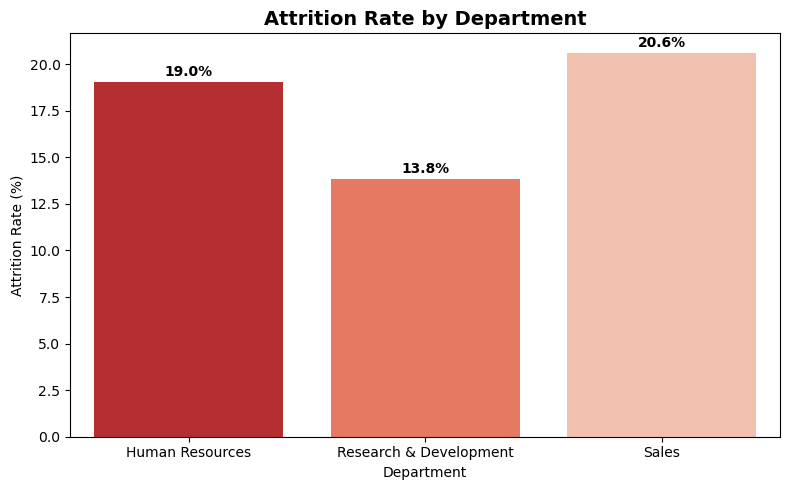

In [14]:
# Block 4 - Attrition by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
dept_attrition.columns = ['Department', 'Attrition_Rate']

print(dept_attrition)

plt.figure(figsize=(8,5))
sns.barplot(data=dept_attrition, x='Department',
            y='Attrition_Rate', palette='Reds_r')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(dept_attrition['Attrition_Rate']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('dept_attrition.png', dpi=150)
plt.show()

  Age_Group  Attrition_Rate
0     18-25       34.782609
1     26-35       19.141914
2     36-45        9.188034
3     46-60       12.454212


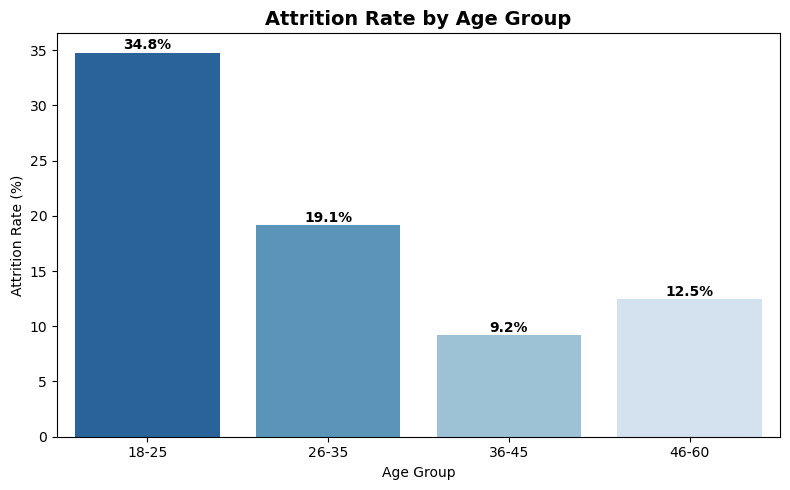

In [15]:
# Block 5 - Attrition by Age Group
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[18,25,35,45,60],
                          labels=['18-25','26-35','36-45','46-60'])

age_attrition = df.groupby('Age_Group', observed=True)['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
age_attrition.columns = ['Age_Group', 'Attrition_Rate']

print(age_attrition)

plt.figure(figsize=(8,5))
sns.barplot(data=age_attrition, x='Age_Group',
            y='Attrition_Rate', palette='Blues_r')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(age_attrition['Attrition_Rate']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('age_attrition.png', dpi=150)
plt.show()

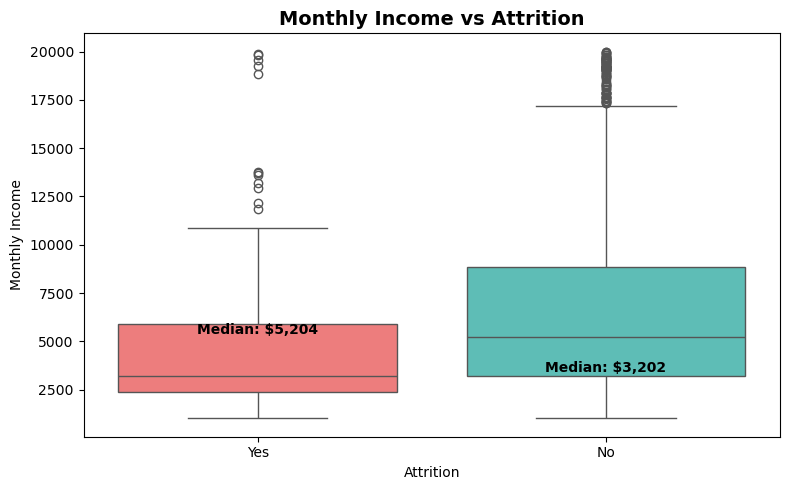

Median Income - Retained: 5204.0
Median Income - Attrition: 3202.0


In [16]:
# Block 6 - Attrition by Monthly Income
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'Yes':'#ff6b6b', 'No':'#4ecdc4'})
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
for i, attrition in enumerate(['No', 'Yes']):
    median = df[df['Attrition']==attrition]['MonthlyIncome'].median()
    plt.text(i, median + 200, f'Median: ${median:,.0f}',
             ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('income_attrition.png', dpi=150)
plt.show()

print("Median Income - Retained:", df[df['Attrition']=='No']['MonthlyIncome'].median())
print("Median Income - Attrition:", df[df['Attrition']=='Yes']['MonthlyIncome'].median())

  Job_Satisfaction  Attrition_Rate
0              Low       22.837370
1           Medium       16.428571
2             High       16.515837
3        Very High       11.328976


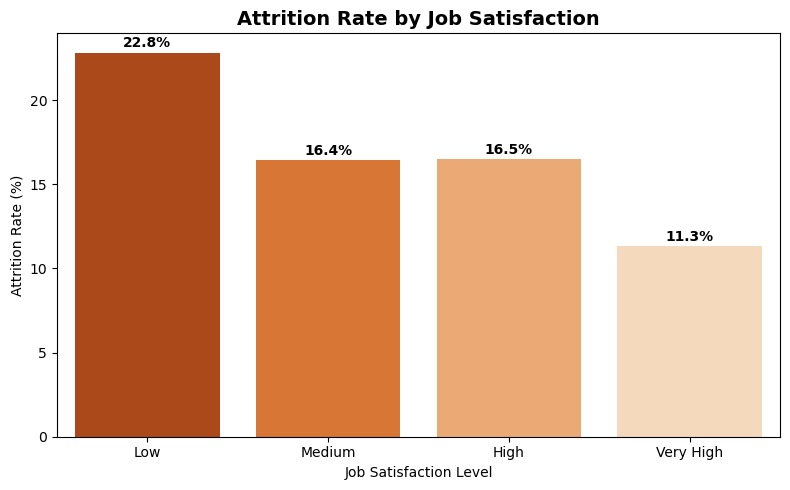

In [17]:
# Block 7 - Attrition by Job Satisfaction
job_sat = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
job_sat.columns = ['Job_Satisfaction', 'Attrition_Rate']
job_sat['Job_Satisfaction'] = job_sat['Job_Satisfaction'].map(
    {1:'Low', 2:'Medium', 3:'High', 4:'Very High'})

print(job_sat)

plt.figure(figsize=(8,5))
sns.barplot(data=job_sat, x='Job_Satisfaction',
            y='Attrition_Rate', palette='Oranges_r',
            order=['Low','Medium','High','Very High'])
plt.title('Attrition Rate by Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(job_sat['Attrition_Rate']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('jobsat_attrition.png', dpi=150)
plt.show()

  WorkLifeBalance  Attrition_Rate
0             Bad       31.250000
1            Good       16.860465
2          Better       14.221725
3            Best       17.647059


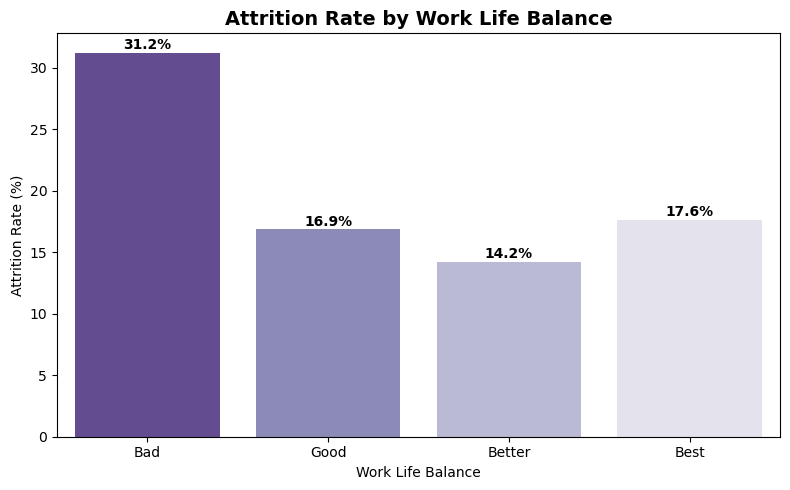

In [18]:
# Block 8 - Attrition by Work Life Balance
wlb = df.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
wlb.columns = ['WorkLifeBalance', 'Attrition_Rate']
wlb['WorkLifeBalance'] = wlb['WorkLifeBalance'].map(
    {1:'Bad', 2:'Good', 3:'Better', 4:'Best'})

print(wlb)

plt.figure(figsize=(8,5))
sns.barplot(data=wlb, x='WorkLifeBalance',
            y='Attrition_Rate', palette='Purples_r',
            order=['Bad','Good','Better','Best'])
plt.title('Attrition Rate by Work Life Balance', fontsize=14, fontweight='bold')
plt.xlabel('Work Life Balance')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(wlb['Attrition_Rate']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('wlb_attrition.png', dpi=150)
plt.show()

In [2]:
# Block 9 - Attrition by Years at Company
plt.figure(figsize=(10,5))
years_attrition = df.groupby('YearsAtCompany')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
years_attrition.columns = ['YearsAtCompany', 'Attrition_Rate']

sns.lineplot(data=years_attrition, x='YearsAtCompany',
             y='Attrition_Rate', color='#ff6b6b',
             linewidth=2.5, marker='o')
plt.title('Attrition Rate by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.axhline(y=16.12, color='gray', linestyle='--', label='Overall Avg 16.12%')
plt.legend()
plt.tight_layout()
plt.savefig('years_attrition.png', dpi=150)
plt.show()

NameError: name 'plt' is not defined

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("✅ Ready! Shape:", df.shape)

✅ Ready! Shape: (1470, 35)


In [20]:
# Block 10 - Save Clean CSV for Power BI (Updated)
df['Attrition_Flag'] = df['Attrition'].apply(
    lambda x: 1 if x == 'Yes' else 0)

df['Age_Group'] = pd.cut(df['Age'],
                          bins=[18,25,35,45,60],
                          labels=['18-25','26-35','36-45','46-60'])

df['Salary_Band'] = pd.cut(df['MonthlyIncome'],
                            bins=[0,3000,6000,10000,20000],
                            labels=['Low','Medium','High','Very High'])

df['JobSatisfaction_Label'] = df['JobSatisfaction'].map(
    {1:'Low', 2:'Medium', 3:'High', 4:'Very High'})

df['WorkLifeBalance_Label'] = df['WorkLifeBalance'].map(
    {1:'Bad', 2:'Good', 3:'Better', 4:'Best'})

# Add Age Group sort order
df['Age_Group_Sort'] = df['Age_Group'].map(
    {'18-25': 1, '26-35': 2, '36-45': 3, '46-60': 4})

df.to_csv('HR_Attrition_Clean.csv', index=False, encoding='utf-8')
print("✅ Clean CSV saved successfully!")
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")

✅ Clean CSV saved successfully!
Total Records: 1470
Total Columns: 41


In [21]:
import pandas as pd
df = pd.read_csv('HR_Attrition_Clean.csv')
print("Total Columns:", len(df.columns))
print("\nColumn Names:")
print(df.columns.tolist())

Total Columns: 41

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag', 'Age_Group', 'Salary_Band', 'JobSatisfaction_Label', 'WorkLifeBalance_Label', 'Age_Group_Sort']


In [1]:
import pandas as pd
df = pd.read_csv('HR_Attrition_Clean.csv')
print("✅ Loaded! Shape:", df.shape)

✅ Loaded! Shape: (1470, 41)


In [2]:
# Add sort columns
df['JobSat_Sort'] = df['JobSatisfaction_Label'].map(
    {'Low':1, 'Medium':2, 'High':3, 'Very High':4})

df['WLB_Sort'] = df['WorkLifeBalance_Label'].map(
    {'Bad':1, 'Good':2, 'Better':3, 'Best':4})

df.to_csv('HR_Attrition_Clean.csv', index=False, encoding='utf-8')
print("✅ Sort columns added!")
print("Total Columns:", len(df.columns))

✅ Sort columns added!
Total Columns: 43
